In [1]:
import os
import random
import torch
import torch.nn as nn
import torchaudio
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
import torch.nn.functional as F
from sklearn.metrics import r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

2025-10-21 05:50:08.107290: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761025808.304072      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761025808.358325      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Emotion label mapping from RAVDESS file name index to string
emotions_dict = {
    '01': 'Neutral',
    '02': 'Calm',
    '03': 'Happy',
    '04': 'Sad',
    '05': 'Angry',
    '06': 'Anxious',  # Fearful renamed as in paper
    '07': 'Disgust',
    '08': 'Surprised'
}

# VAD mapping from the paper (normalized to 0–1)
emotion_to_vad_map = {
    'Neutral':  [0.883, 0.170, 0.304],
    'Calm':     [0.744, 0.085, 0.191],
    'Happy':    [0.987, 0.529, 0.596],
    'Sad':      [0.736, 0.305, 0.401],
    'Angry':    [0.235, 0.863, 0.918],
    'Anxious':  [0.431, 0.607, 0.415],
    'Disgust':  [0.397, 0.386, 0.493],
    'Surprised':[0.709, 0.623, 0.683]
}

# Emotion → Valence group mapping
emotion_valence_map = {
    'Happy': 'High',
    'Calm': 'High',
    'Surprised': 'Medium',
    'Neutral': 'Medium',
    'Sad': 'Low',
    'Angry': 'Low',
    'Anxious': 'Low',
    'Disgust': 'Low'
}

In [3]:
data_root = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24"
people_dict_addr = {}
people_dict_vad = {}

for dirname, _, filenames in os.walk(data_root):
    for filename in filenames:
        addr = os.path.join(dirname, filename)
        parts = filename.split('-')
        emotion_code = parts[2]
        speaker_id = int(addr.split('/')[5].split('_')[1])
        emotion_label = emotions_dict[emotion_code]

        # Get VAD target
        vad_target = torch.tensor(emotion_to_vad_map[emotion_label], dtype=torch.float32)

        if speaker_id not in people_dict_addr:
            people_dict_addr[speaker_id] = []
            people_dict_vad[speaker_id] = []

        people_dict_addr[speaker_id].append(addr)
        people_dict_vad[speaker_id].append(vad_target)


In [4]:
all_speakers = list(people_dict_addr.keys())
random.seed(42)
random.shuffle(all_speakers)

split = int(len(all_speakers) * 0.8)
train_speakers = all_speakers[:split]
test_speakers = all_speakers[split:]

def collect_files(speaker_list):
    files, vads = [], []
    for spk in speaker_list:
        files.extend(people_dict_addr[spk])
        vads.extend(people_dict_vad[spk])
    return files, vads

train_files, train_vads = collect_files(train_speakers)
test_files, test_vads = collect_files(test_speakers)


In [5]:
class VADDataset(Dataset):
    def __init__(self, file_list, vad_targets, feature_extractor, max_duration = 5.27, target_sr = 16000):
        self.file_list = file_list
        self.vad_targets = vad_targets
        self.feature_extractor = feature_extractor
        self.max_duration = max_duration
        self.target_sr = target_sr 
        
    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path = self.file_list[idx]
        vad = self.vad_targets[idx]

        waveform, sr = torchaudio.load(path)

        # Dynamically resample to target sampling rate 
        if sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq = self.target_sr)
            waveform = resampler(waveform)
            
        # Convert to mono explicitly to ensure consistent shape
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            
        #  Normalize to zero mean and unit variance
        waveform = F.layer_norm(waveform, waveform.shape)

        waveform = waveform.squeeze(0).numpy()
        inputs = self.feature_extractor(
            waveform,
            sampling_rate=self.target_sr,
            return_tensors="pt",
            padding="max_length",
            max_length=int(self.max_duration * self.target_sr),  # 5.27 * 16000
            truncation=True
        )
        
        input_values = inputs.input_values.squeeze(0)         
        attention_mask = inputs.attention_mask.squeeze(0)     

        return input_values, attention_mask, vad


In [6]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition")

train_dataset = VADDataset(train_files, train_vads, feature_extractor)
test_dataset = VADDataset(test_files, test_vads, feature_extractor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

In [7]:
class Wav2Vec2_LSTM_VAD(nn.Module):
    def __init__(self, pretrained_model_name='ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition'):
        super(Wav2Vec2_LSTM_VAD, self).__init__()

        # Load pretrained Wav2Vec2 model
        self.wav2vec = Wav2Vec2Model.from_pretrained(pretrained_model_name)
        self.wav2vec.eval()
        # Freeze by default
        # for param in self.wav2vec.parameters():
        #     param.requires_grad = False

        # LSTM layer
        self.lstm = nn.LSTM(input_size=1024, hidden_size=256, batch_first=True)

        # Fully connected layers
        self.fc1 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, 256)
        
        self.out = nn.Linear(256, 3)  # Output: Valence, Arousal, Dominance
        
    def forward(self, input_values, attention_mask=None):
        input_values = input_values.to(device)
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)

        with torch.no_grad():
            wav2vec_out = self.wav2vec(input_values, attention_mask=attention_mask).last_hidden_state

        lstm_out, _ = self.lstm(wav2vec_out)
        last_hidden = lstm_out[:, -1, :]

        x = self.fc1(last_hidden)
        x = self.fc2(x)
        vad_out = self.out(x)

        return vad_out


In [8]:
model = Wav2Vec2_LSTM_VAD().to(device)

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:311: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

In [9]:
def mean_squared_error(y_true, y_pred):
    return F.mse_loss(y_pred, y_true).item()

def euclidean_distance(y_true, y_pred):
    diff = y_pred - y_true
    dist = torch.norm(diff, dim=1)
    return dist.mean().item()

def r2_score_metric(y_true, y_pred):
    return r2_score(y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy())

In [10]:
def train_model(model, train_loader, val_loader, optimizer, num_epochs):
    best_loss = float('inf')
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Track metrics
    train_losses = []
    val_losses = []
    val_r2_scores = []
    val_euclidean = []

    for epoch in range(num_epochs):
        model.train()
        batch_losses = []

        for input_values, attention_mask, vad in train_loader:
            input_values, attention_mask, vad = input_values.to(device), attention_mask.to(device), vad.to(device)

            optimizer.zero_grad()
            outputs = model(input_values, attention_mask)
            loss = F.mse_loss(outputs, vad)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = sum(batch_losses) / len(batch_losses)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_batch_losses, val_r2s, val_eucs = [], [], []
        
        

        with torch.no_grad():
            for input_values, attention_mask, vad in val_loader:
        
                input_values, attention_mask, vad = input_values.to(device), attention_mask.to(device), vad.to(device)
                outputs = model(input_values, attention_mask)

                val_loss = F.mse_loss(outputs, vad)
                val_r2 = r2_score_metric(vad, outputs)
                val_euc = euclidean_distance(vad, outputs)

                val_batch_losses.append(val_loss.item())
                val_r2s.append(val_r2)
                val_eucs.append(val_euc)

        val_losses.append(np.mean(val_batch_losses))
        val_r2_scores.append(np.mean(val_r2s))
        val_euclidean.append(np.mean(val_eucs))

        print(f"[Epoch {epoch+1}] Train MSE: {train_loss:.4f} | Val MSE: {val_losses[-1]:.4f} | R²: {val_r2_scores[-1]:.4f} | Euc: {val_euclidean[-1]:.4f}")
        
        # saving the best model
        if val_losses[-1] < best_loss:
            best_loss = val_losses[-1]
            torch.save(model.state_dict(), "best_model.pt")
    
    torch.save(model.state_dict(), "final_model.pt")    

    # Return metrics for plotting
    return train_losses, val_losses, val_euclidean, val_r2_scores

In [11]:
# optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
result = train_model(model, train_loader, test_loader, optimizer, num_epochs=100)
if result is not None:
    train_losses, val_losses, val_euclidean, val_r2_scores = result

/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


[Epoch 1] Train MSE: 0.0291 | Val MSE: 0.0135 | R²: 0.7474 | Euc: 0.1502


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


[Epoch 2] Train MSE: 0.0099 | Val MSE: 0.0070 | R²: 0.8747 | Euc: 0.1111


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


...

[Epoch 98] Train MSE: 0.0047 | Val MSE: 0.0039 | R²: 0.9314 | Euc: 0.0591


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


[Epoch 99] Train MSE: 0.0046 | Val MSE: 0.0040 | R²: 0.9295 | Euc: 0.0565


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


[Epoch 100] Train MSE: 0.0062 | Val MSE: 0.0051 | R²: 0.9095 | Euc: 0.0722


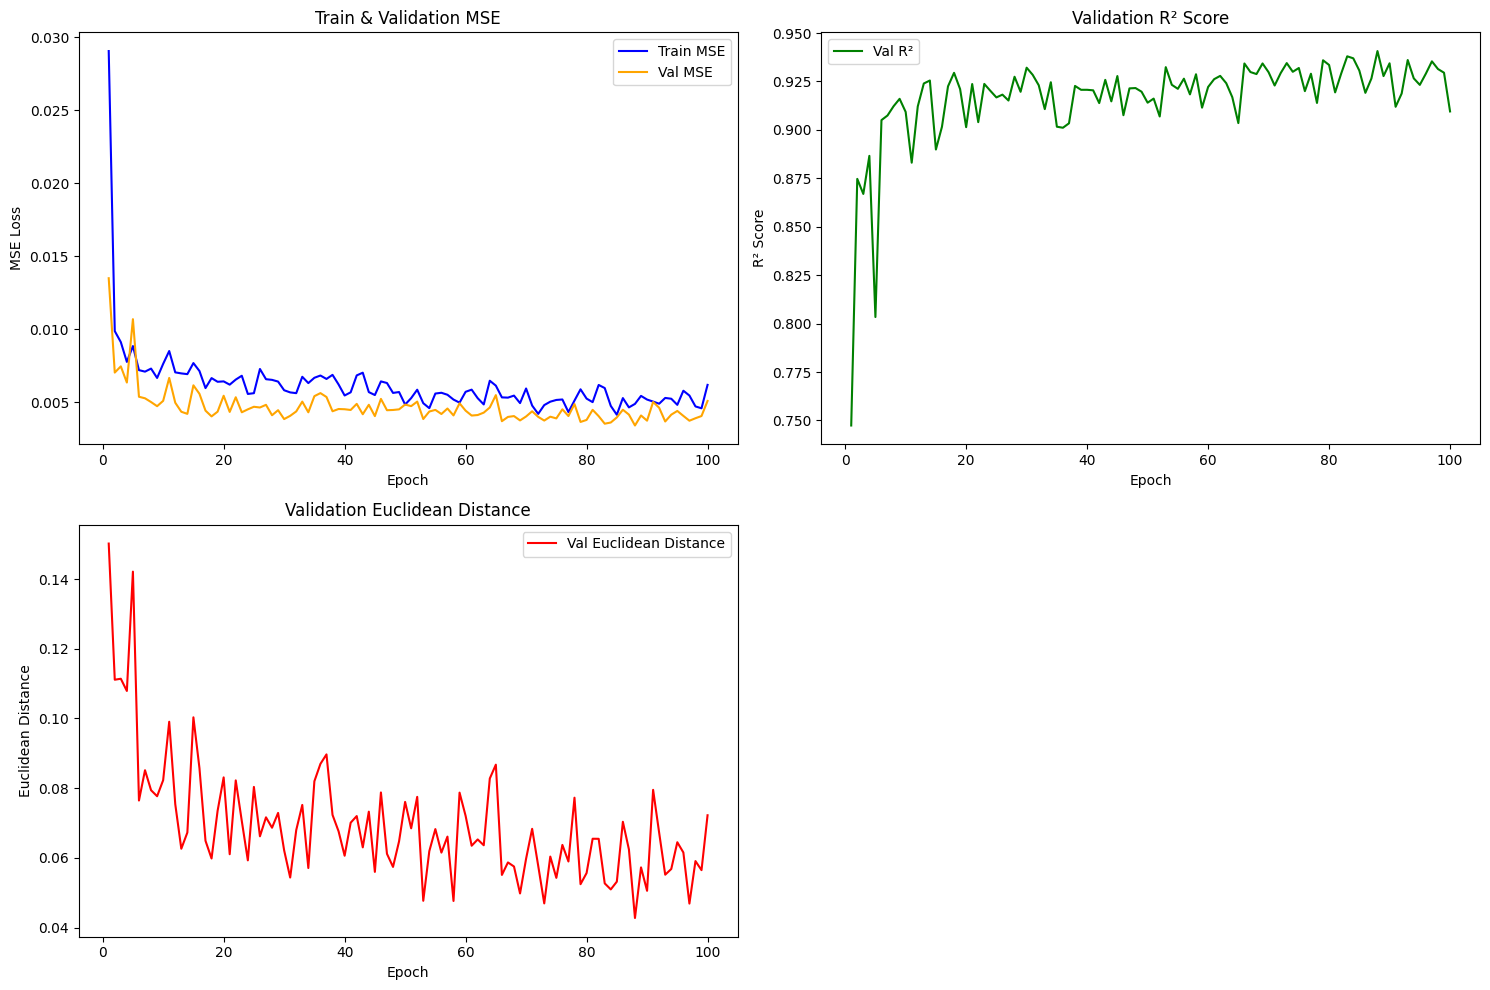

In [12]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(15, 10))

# Train vs Val Loss
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses, label="Train MSE", color='blue')
plt.plot(epochs, val_losses, label="Val MSE", color='orange')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Train & Validation MSE")
plt.legend()

# R² Score
plt.subplot(2, 2, 2)
plt.plot(epochs, val_r2_scores, label="Val R²", color='green')
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Validation R² Score")
plt.legend()

# Euclidean Distance
plt.subplot(2, 2, 3)
plt.plot(epochs, val_euclidean, label="Val Euclidean Distance", color='red')
plt.xlabel("Epoch")
plt.ylabel("Euclidean Distance")
plt.title("Validation Euclidean Distance")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import r2_score
import numpy as np
import torch.nn.functional as F

# Helper function for Euclidean distance
def euclidean_distance(preds, targets):
    return np.mean(np.linalg.norm(preds - targets, axis=1))

def evaluate(model, test_loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for input_values, attention_mask, vad in test_loader:
            input_values = input_values.to(device)
            attention_mask = attention_mask.to(device)
            vad = vad.to(device)

            outputs = model(input_values, attention_mask)
            all_preds.append(outputs.cpu())
            all_targets.append(vad.cpu())

    preds = torch.cat(all_preds, dim=0).numpy()
    targets = torch.cat(all_targets, dim=0).numpy()

    mse = np.mean((preds - targets) ** 2)
    r2 = r2_score(targets, preds)
    eucl = euclidean_distance(preds, targets)

    print(f"MSE: {mse:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Euclidean Distance: {eucl:.4f}")
    
    return preds, targets


In [14]:
import numpy as np

def get_k_nearest_emotions(vad, k=1):
    vad = np.array(vad)
    distances = [(label, np.linalg.norm(vad - np.array(v))) for label, v in emotion_to_vad_map.items()]
    distances.sort(key=lambda x: x[1])  # Sort by distance
    return [label for label, _ in distances[:k]]  # Return top-k labels

def knn_classification_accuracy(preds, targets, k=1):
    correct = 0
    for pred, true in zip(preds, targets):
        nearest = get_k_nearest_emotions(pred, k)
        true_label = closest_emotion(true)  # ground truth label
        if true_label in nearest:
            correct += 1
    acc = correct / len(preds)
    print(f"{k}-NN Classification Accuracy (VAD → emotion): {acc:.4f}")

def closest_emotion(vad):
    vad = np.array(vad)
    return min(emotion_to_vad_map.items(), key=lambda item: np.linalg.norm(vad - np.array(item[1])))[0]


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

def plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=1, title_prefix="Confusion Matrix"):
    """
    Computes and plots two confusion matrices:
    1. Emotion-level matrix using nearest VAD centroids.
    2. Valence-level matrix (High, Medium, Low) using emotion-to-valence grouping.

    Args:
        preds (np.ndarray): Predicted VAD values (N x 3)
        targets (np.ndarray): True VAD values (N x 3)
        emotion_to_vad_map (dict): Dictionary mapping emotions to VAD coordinates.
        emotion_valence_map (dict): Mapping of emotions to valence category (High/Medium/Low).
        k (int): Number of nearest neighbors to consider (e.g., 1, 2, or 3).
        title_prefix (str): Prefix for plot titles.
    """

    def top_k_emotions(vad, k):
        vad = np.array(vad)
        distances = [(label, np.linalg.norm(vad - np.array(v))) for label, v in emotion_to_vad_map.items()]
        distances.sort(key=lambda x: x[1])
        return [label for label, _ in distances[:k]]

    def closest_emotion(vad):
        return top_k_emotions(vad, k=1)[0]

    # Emotion labels (for consistent layout)
    emotion_labels = list(emotion_to_vad_map.keys())

    # Convert targets and preds to discrete emotion predictions
    y_true_emotion = [closest_emotion(t) for t in targets]

    if k == 1:
        y_pred_emotion = [closest_emotion(p) for p in preds]
    else:
        y_pred_emotion = []
        for p, t in zip(preds, targets):
            top_k = top_k_emotions(p, k)
            true_label = closest_emotion(t)
            y_pred_emotion.append(true_label if true_label in top_k else top_k[0])

    # Compute emotion-level confusion matrix
    cm_emotion = confusion_matrix(y_true_emotion, y_pred_emotion, labels=emotion_labels)
    cm_emotion_norm = cm_emotion.astype('float') / cm_emotion.sum(axis=1)[:, np.newaxis]
    cm_emotion_norm = np.nan_to_num(cm_emotion_norm)
    acc_emotion = accuracy_score(y_true_emotion, y_pred_emotion) * 100

    # ----------------------------
    # Valence-level confusion matrix
    # ----------------------------

    # Map each emotion to a valence category (High/Medium/Low)
    def emotion_to_valence_category(emotion):
        return emotion_valence_map.get(emotion, "Medium")

    y_true_val = [emotion_to_valence_category(e) for e in y_true_emotion]
    y_pred_val = [emotion_to_valence_category(e) for e in y_pred_emotion]

    valence_labels = ["Low", "Medium", "High"]

    cm_valence = confusion_matrix(y_true_val, y_pred_val, labels=valence_labels)
    cm_valence_norm = cm_valence.astype('float') / cm_valence.sum(axis=1)[:, np.newaxis]
    cm_valence_norm = np.nan_to_num(cm_valence_norm)
    acc_valence = accuracy_score(y_true_val, y_pred_val) * 100

    # ----------------------------
    # Plot both confusion matrices
    # ----------------------------
    fig, axs = plt.subplots(1, 2, figsize=(18, 7))

    # Emotion-level
    im1 = axs[0].imshow(cm_emotion_norm, interpolation='nearest', cmap=plt.cm.Blues)
    axs[0].set_title(f'{title_prefix} (Emotions, Top-{k}, Acc={acc_emotion:.2f}%)')
    axs[0].set_xticks(np.arange(len(emotion_labels)))
    axs[0].set_yticks(np.arange(len(emotion_labels)))
    axs[0].set_xticklabels(emotion_labels, rotation=45)
    axs[0].set_yticklabels(emotion_labels)
    axs[0].set_ylabel("True Emotion")
    axs[0].set_xlabel("Predicted Emotion")

    # Annotate cells
    thresh = cm_emotion_norm.max() / 2.
    for i in range(cm_emotion.shape[0]):
        for j in range(cm_emotion.shape[1]):
            axs[0].text(j, i, f"{cm_emotion[i, j]}\n({cm_emotion_norm[i, j]:.2f})",
                        ha="center", va="center",
                        color="white" if cm_emotion_norm[i, j] > thresh else "black")

    fig.colorbar(im1, ax=axs[0])

    # Valence-level
    im2 = axs[1].imshow(cm_valence_norm, interpolation='nearest', cmap=plt.cm.Greens)
    axs[1].set_title(f'{title_prefix} (Valence, Top-{k}, Acc={acc_valence:.2f}%)')
    axs[1].set_xticks(np.arange(len(valence_labels)))
    axs[1].set_yticks(np.arange(len(valence_labels)))
    axs[1].set_xticklabels(valence_labels)
    axs[1].set_yticklabels(valence_labels)
    axs[1].set_ylabel("True Valence")
    axs[1].set_xlabel("Predicted Valence")

    thresh2 = cm_valence_norm.max() / 2.
    for i in range(cm_valence.shape[0]):
        for j in range(cm_valence.shape[1]):
            axs[1].text(j, i, f"{cm_valence[i, j]}\n({cm_valence_norm[i, j]:.2f})",
                        ha="center", va="center",
                        color="white" if cm_valence_norm[i, j] > thresh2 else "black")

    fig.colorbar(im2, ax=axs[1])

    plt.tight_layout()
    plt.show()

    # Print reports
    print(f"\n--- Emotion Classification Report ---")
    print(classification_report(y_true_emotion, y_pred_emotion, labels=emotion_labels, target_names=emotion_labels))
    print(f"Emotion-Level Accuracy: {acc_emotion:.2f}%")

    print(f"\n--- Valence Classification Report ---")
    print(classification_report(y_true_val, y_pred_val, labels=valence_labels, target_names=valence_labels))
    print(f"Valence-Level Accuracy: {acc_valence:.2f}%")


## Evaluation on final model 

In [16]:
# evaluate the final model on test data 
preds, targets = evaluate(model, test_loader)

# Classification accuracy ( Remember these are not normalized accuracy score)
knn_classification_accuracy(preds, targets,k=1)
knn_classification_accuracy(preds, targets,k=2)
knn_classification_accuracy(preds, targets,k=3)

MSE: 0.0045
R²: 0.9173
Euclidean Distance: 0.0708
1-NN Classification Accuracy (VAD → emotion): 0.9267
2-NN Classification Accuracy (VAD → emotion): 0.9533
3-NN Classification Accuracy (VAD → emotion): 0.9867


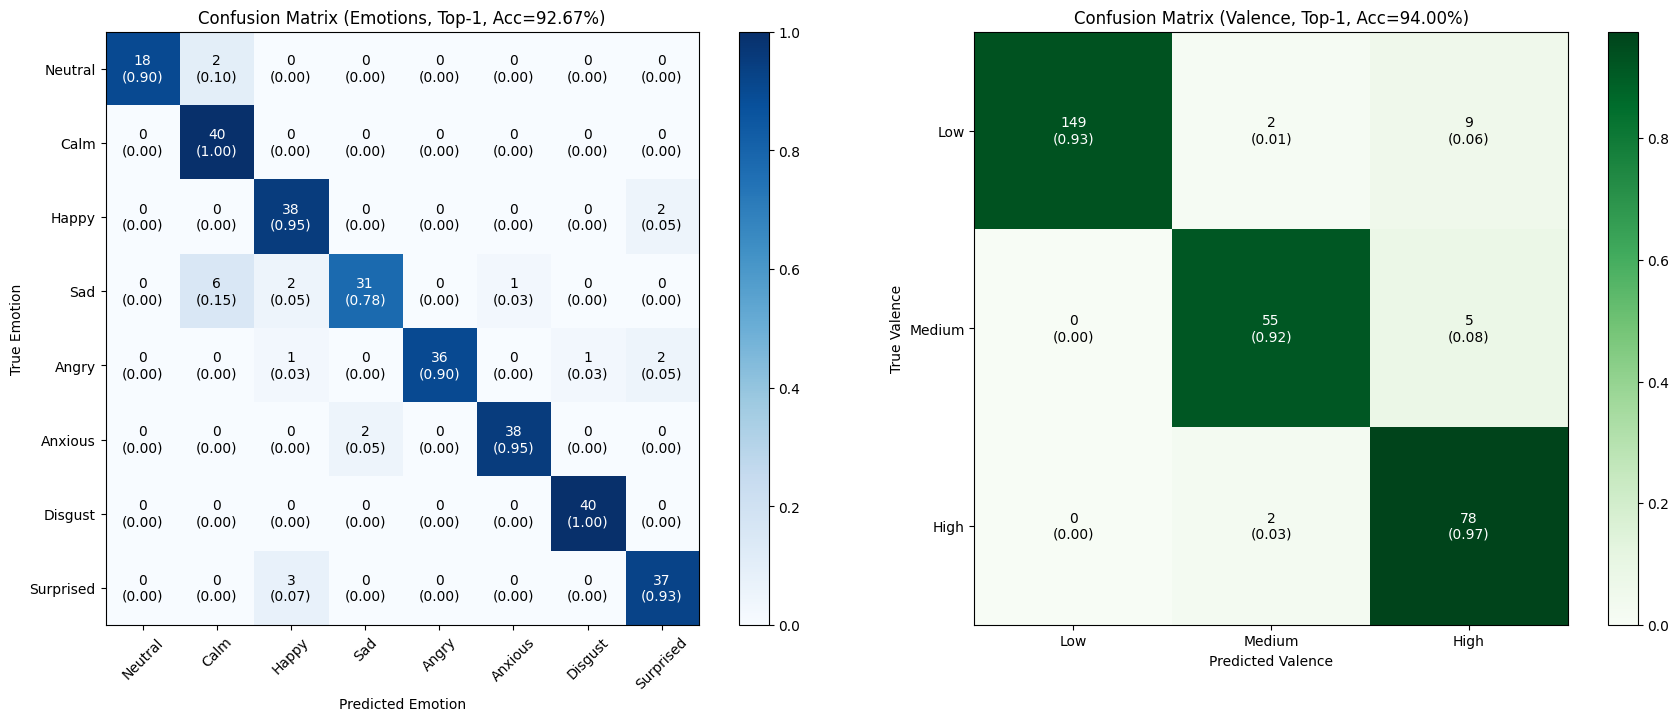


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       1.00      0.90      0.95        20
        Calm       0.83      1.00      0.91        40
       Happy       0.86      0.95      0.90        40
         Sad       0.94      0.78      0.85        40
       Angry       1.00      0.90      0.95        40
     Anxious       0.97      0.95      0.96        40
     Disgust       0.98      1.00      0.99        40
   Surprised       0.90      0.93      0.91        40

    accuracy                           0.93       300
   macro avg       0.94      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

Emotion-Level Accuracy: 92.67%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       1.00      0.93      0.96       160
      Medium       0.93      0.92      0.92        60
        High       0.85      0.97      0.91        80

    accuracy          

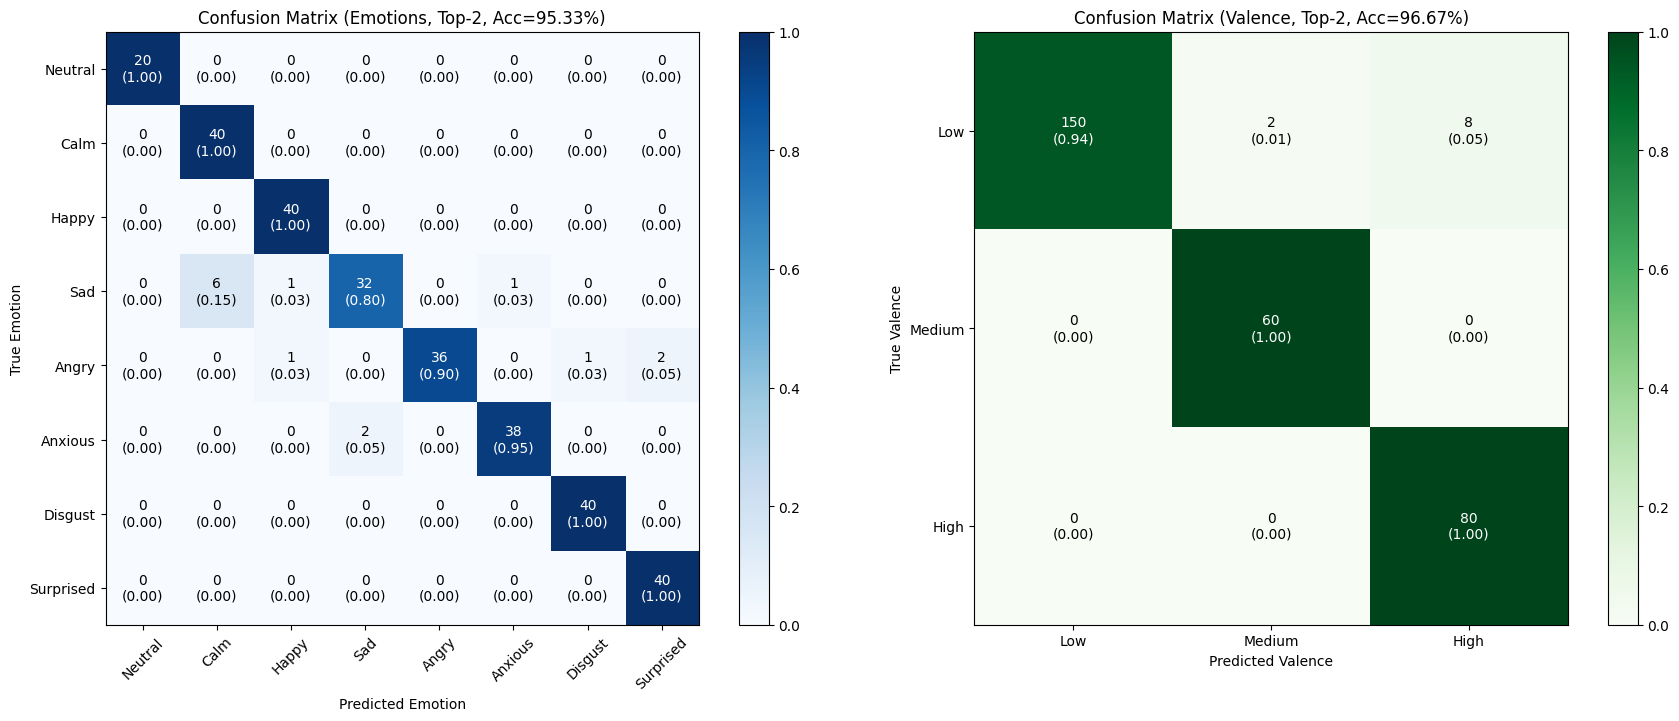


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       1.00      1.00      1.00        20
        Calm       0.87      1.00      0.93        40
       Happy       0.95      1.00      0.98        40
         Sad       0.94      0.80      0.86        40
       Angry       1.00      0.90      0.95        40
     Anxious       0.97      0.95      0.96        40
     Disgust       0.98      1.00      0.99        40
   Surprised       0.95      1.00      0.98        40

    accuracy                           0.95       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.95      0.95       300

Emotion-Level Accuracy: 95.33%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       1.00      0.94      0.97       160
      Medium       0.97      1.00      0.98        60
        High       0.91      1.00      0.95        80

    accuracy          

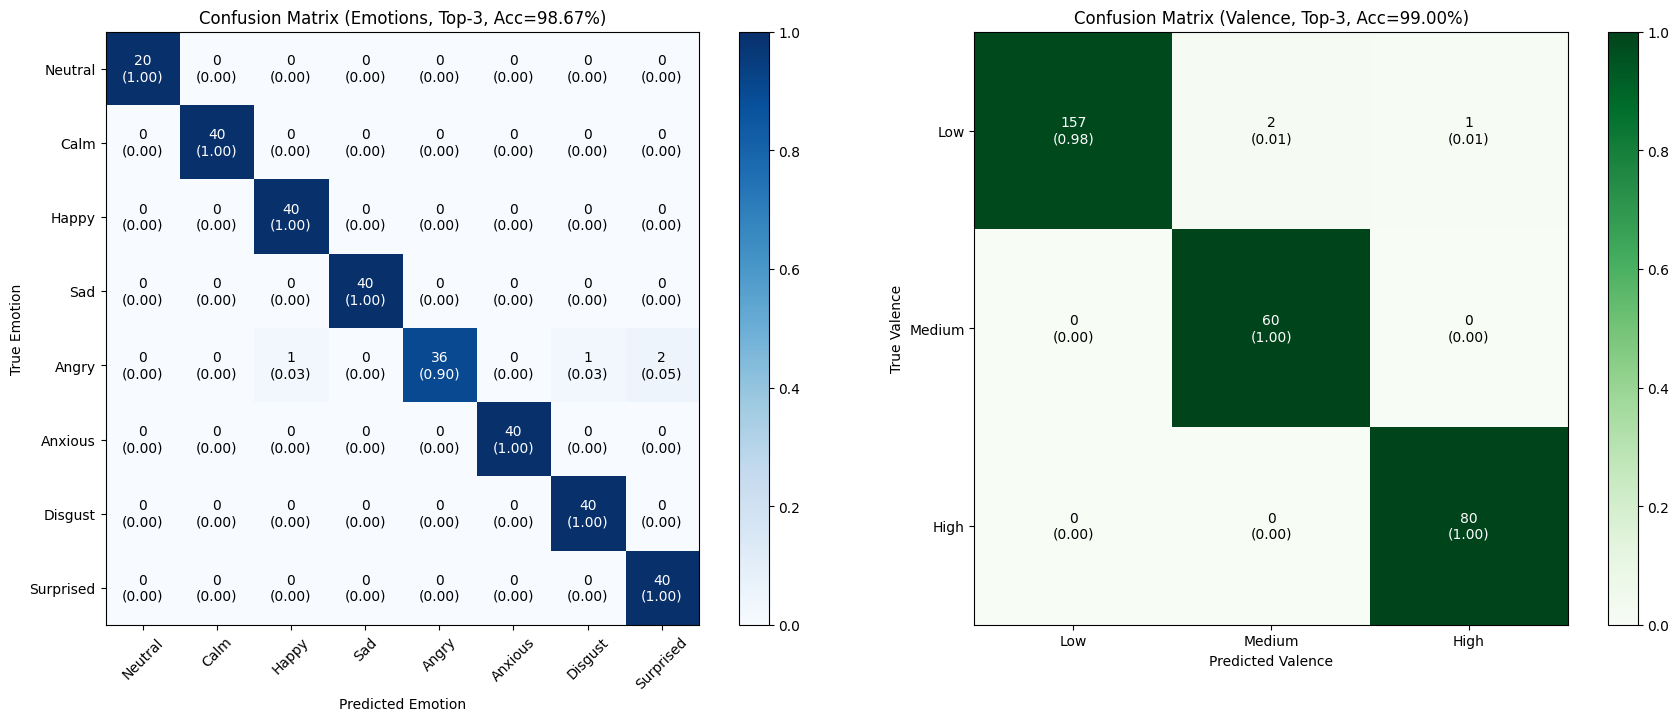


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       1.00      1.00      1.00        20
        Calm       1.00      1.00      1.00        40
       Happy       0.98      1.00      0.99        40
         Sad       1.00      1.00      1.00        40
       Angry       1.00      0.90      0.95        40
     Anxious       1.00      1.00      1.00        40
     Disgust       0.98      1.00      0.99        40
   Surprised       0.95      1.00      0.98        40

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

Emotion-Level Accuracy: 98.67%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       1.00      0.98      0.99       160
      Medium       0.97      1.00      0.98        60
        High       0.99      1.00      0.99        80

    accuracy          

In [17]:
# here normalized accuracy score is printed
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=1)
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=2)
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=3)

In [18]:
# evaluate the final model on train data
preds, targets = evaluate(model, train_loader)

# Classification accuracy ( Remember these are not normalized accuracy score)
knn_classification_accuracy(preds, targets,k=1)
knn_classification_accuracy(preds, targets,k=2)
knn_classification_accuracy(preds, targets,k=3)

MSE: 0.0050
R²: 0.9100
Euclidean Distance: 0.0789
1-NN Classification Accuracy (VAD → emotion): 0.9061
2-NN Classification Accuracy (VAD → emotion): 0.9544
3-NN Classification Accuracy (VAD → emotion): 0.9728


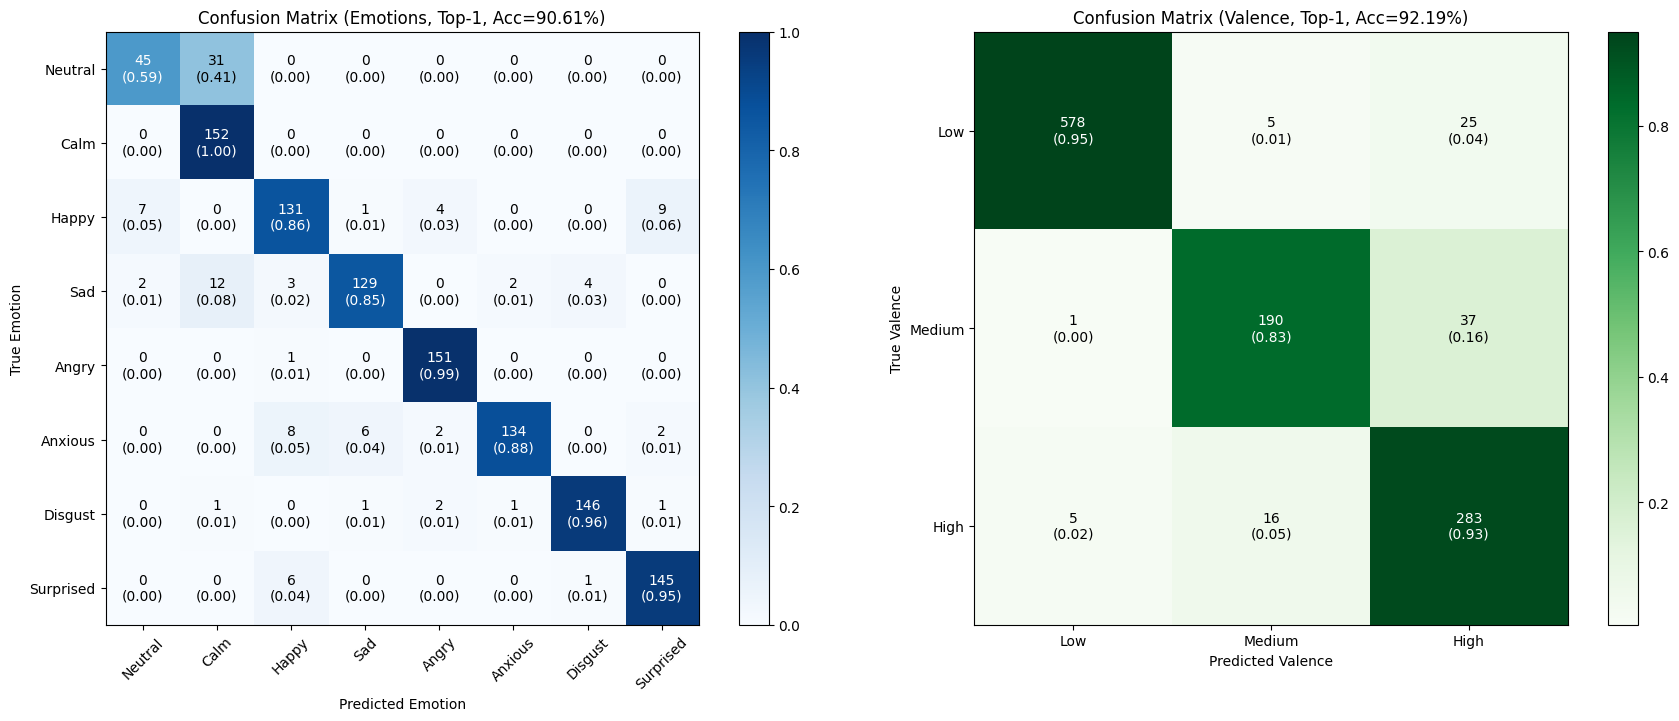


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       0.83      0.59      0.69        76
        Calm       0.78      1.00      0.87       152
       Happy       0.88      0.86      0.87       152
         Sad       0.94      0.85      0.89       152
       Angry       0.95      0.99      0.97       152
     Anxious       0.98      0.88      0.93       152
     Disgust       0.97      0.96      0.96       152
   Surprised       0.92      0.95      0.94       152

    accuracy                           0.91      1140
   macro avg       0.91      0.89      0.89      1140
weighted avg       0.91      0.91      0.90      1140

Emotion-Level Accuracy: 90.61%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       0.99      0.95      0.97       608
      Medium       0.90      0.83      0.87       228
        High       0.82      0.93      0.87       304

    accuracy          

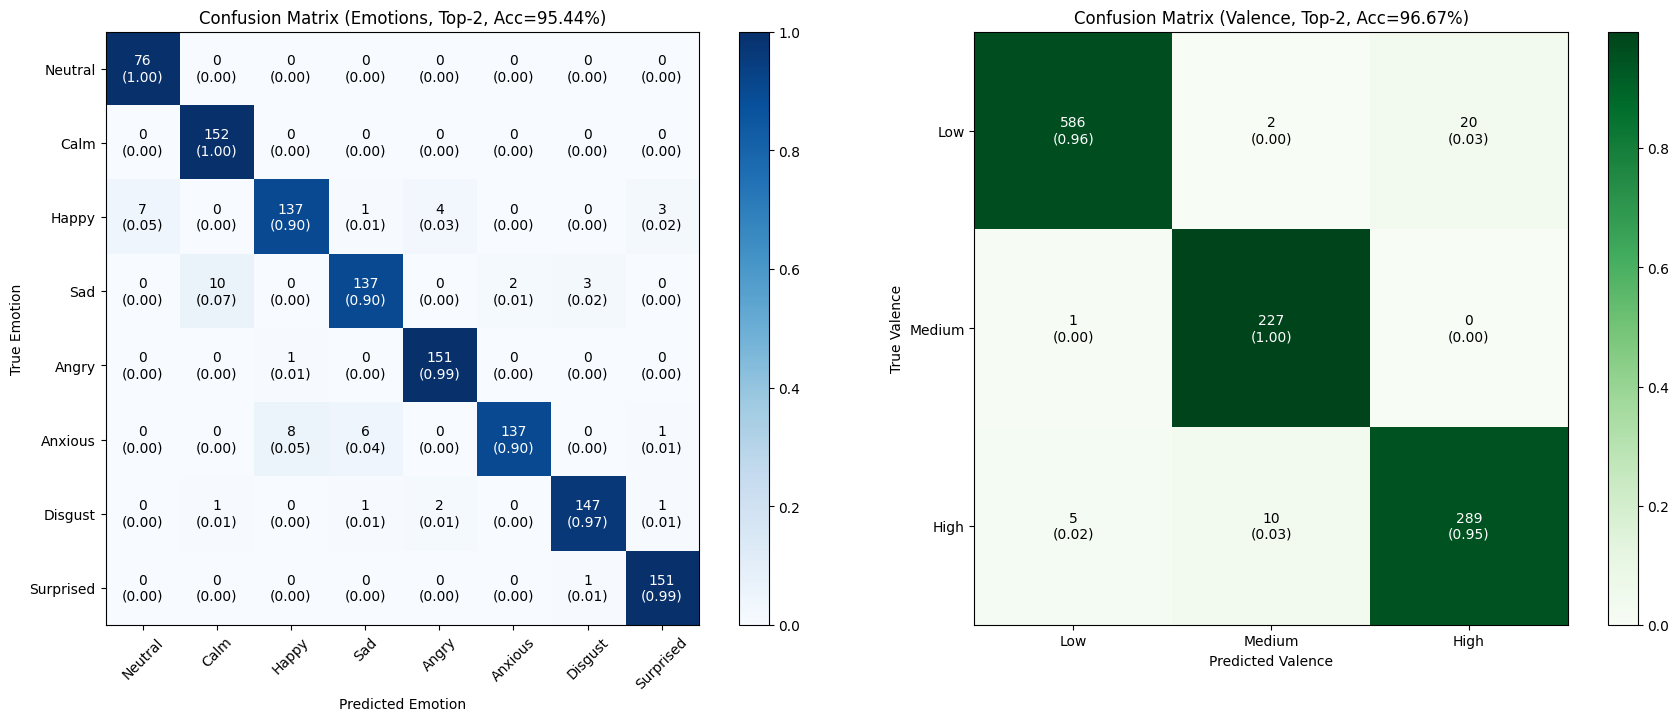


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       0.92      1.00      0.96        76
        Calm       0.93      1.00      0.97       152
       Happy       0.94      0.90      0.92       152
         Sad       0.94      0.90      0.92       152
       Angry       0.96      0.99      0.98       152
     Anxious       0.99      0.90      0.94       152
     Disgust       0.97      0.97      0.97       152
   Surprised       0.97      0.99      0.98       152

    accuracy                           0.95      1140
   macro avg       0.95      0.96      0.95      1140
weighted avg       0.95      0.95      0.95      1140

Emotion-Level Accuracy: 95.44%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       0.99      0.96      0.98       608
      Medium       0.95      1.00      0.97       228
        High       0.94      0.95      0.94       304

    accuracy          

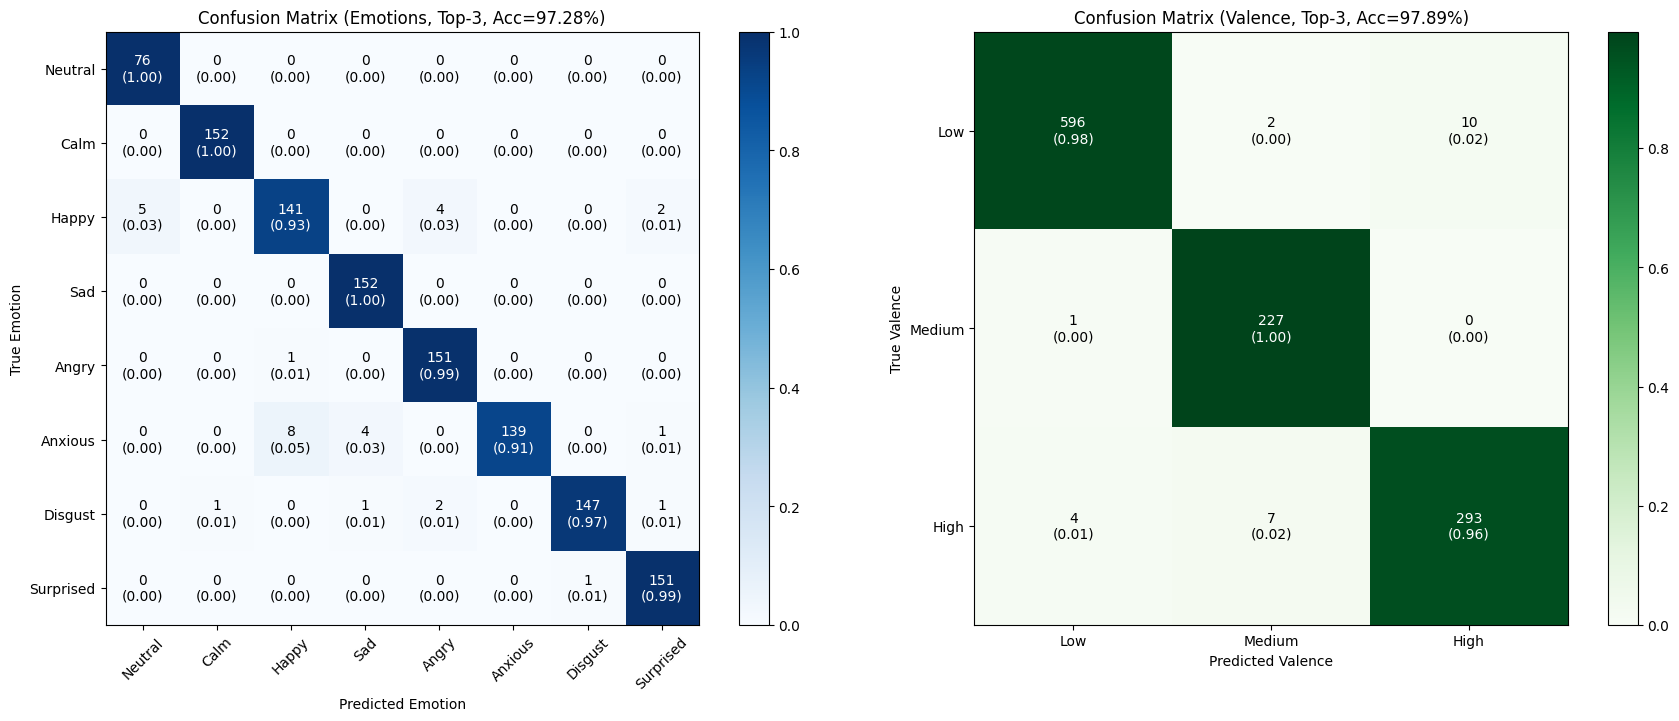


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       0.94      1.00      0.97        76
        Calm       0.99      1.00      1.00       152
       Happy       0.94      0.93      0.93       152
         Sad       0.97      1.00      0.98       152
       Angry       0.96      0.99      0.98       152
     Anxious       1.00      0.91      0.96       152
     Disgust       0.99      0.97      0.98       152
   Surprised       0.97      0.99      0.98       152

    accuracy                           0.97      1140
   macro avg       0.97      0.97      0.97      1140
weighted avg       0.97      0.97      0.97      1140

Emotion-Level Accuracy: 97.28%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       0.99      0.98      0.99       608
      Medium       0.96      1.00      0.98       228
        High       0.97      0.96      0.97       304

    accuracy          

In [19]:
# here normalized accuracy score is printed
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=1)
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=2)
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=3)

## Evaluation on Best Model 

In [20]:
model = Wav2Vec2_LSTM_VAD()
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.to(device)
model.eval()


/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:311: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Wav2Vec2_LSTM_VAD(
  (wav2vec): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (proj

In [21]:
# evaluate the best model on test data 
preds, targets = evaluate(model, test_loader)

# Classification accuracy ( Remember these are not normalized accuracy score)
knn_classification_accuracy(preds, targets,k=1)
knn_classification_accuracy(preds, targets,k=2)
knn_classification_accuracy(preds, targets,k=3)

MSE: 0.0028
R²: 0.9480
Euclidean Distance: 0.0408
1-NN Classification Accuracy (VAD → emotion): 0.9567
2-NN Classification Accuracy (VAD → emotion): 0.9667
3-NN Classification Accuracy (VAD → emotion): 0.9867


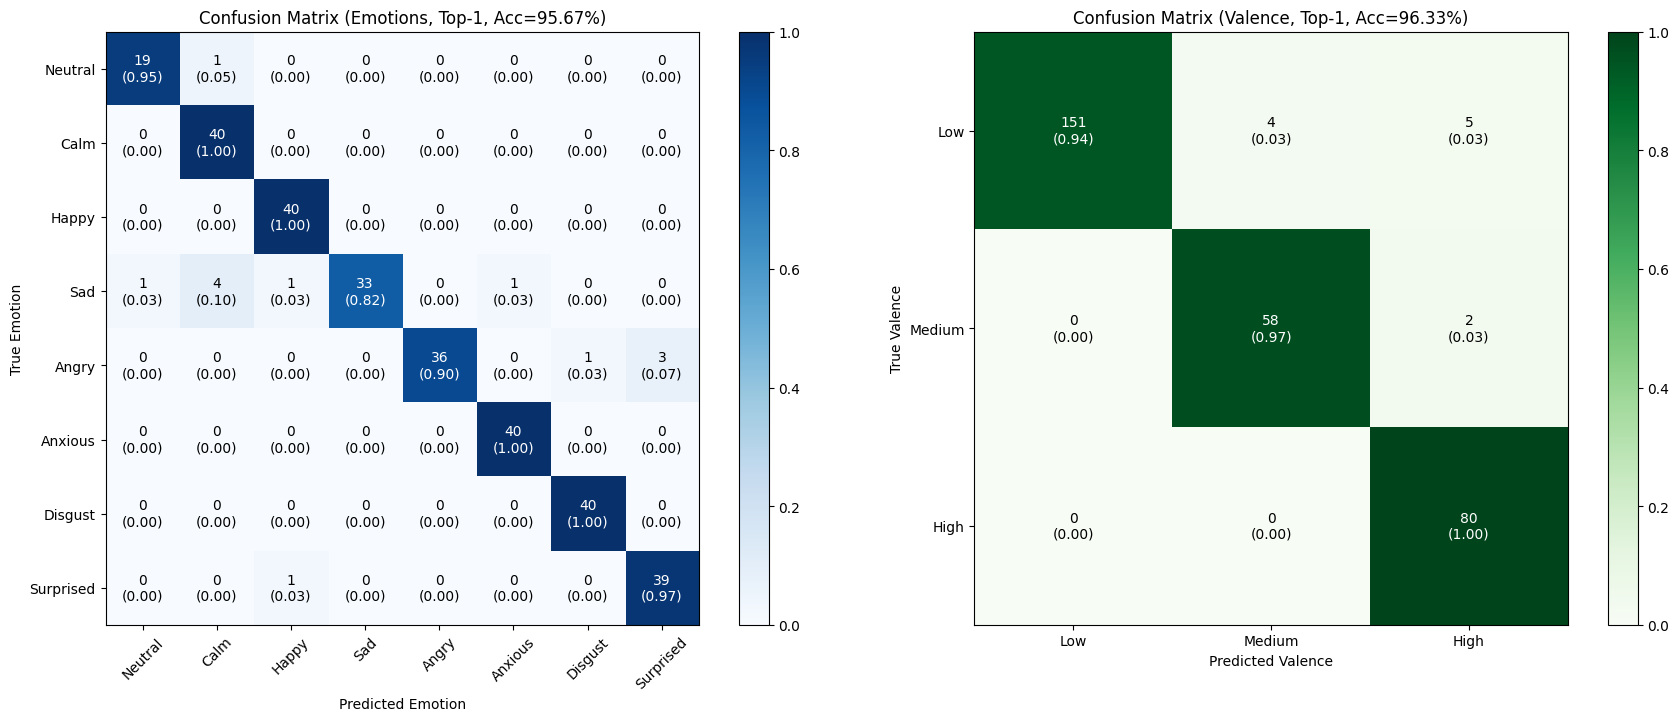


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       0.95      0.95      0.95        20
        Calm       0.89      1.00      0.94        40
       Happy       0.95      1.00      0.98        40
         Sad       1.00      0.82      0.90        40
       Angry       1.00      0.90      0.95        40
     Anxious       0.98      1.00      0.99        40
     Disgust       0.98      1.00      0.99        40
   Surprised       0.93      0.97      0.95        40

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

Emotion-Level Accuracy: 95.67%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       1.00      0.94      0.97       160
      Medium       0.94      0.97      0.95        60
        High       0.92      1.00      0.96        80

    accuracy          

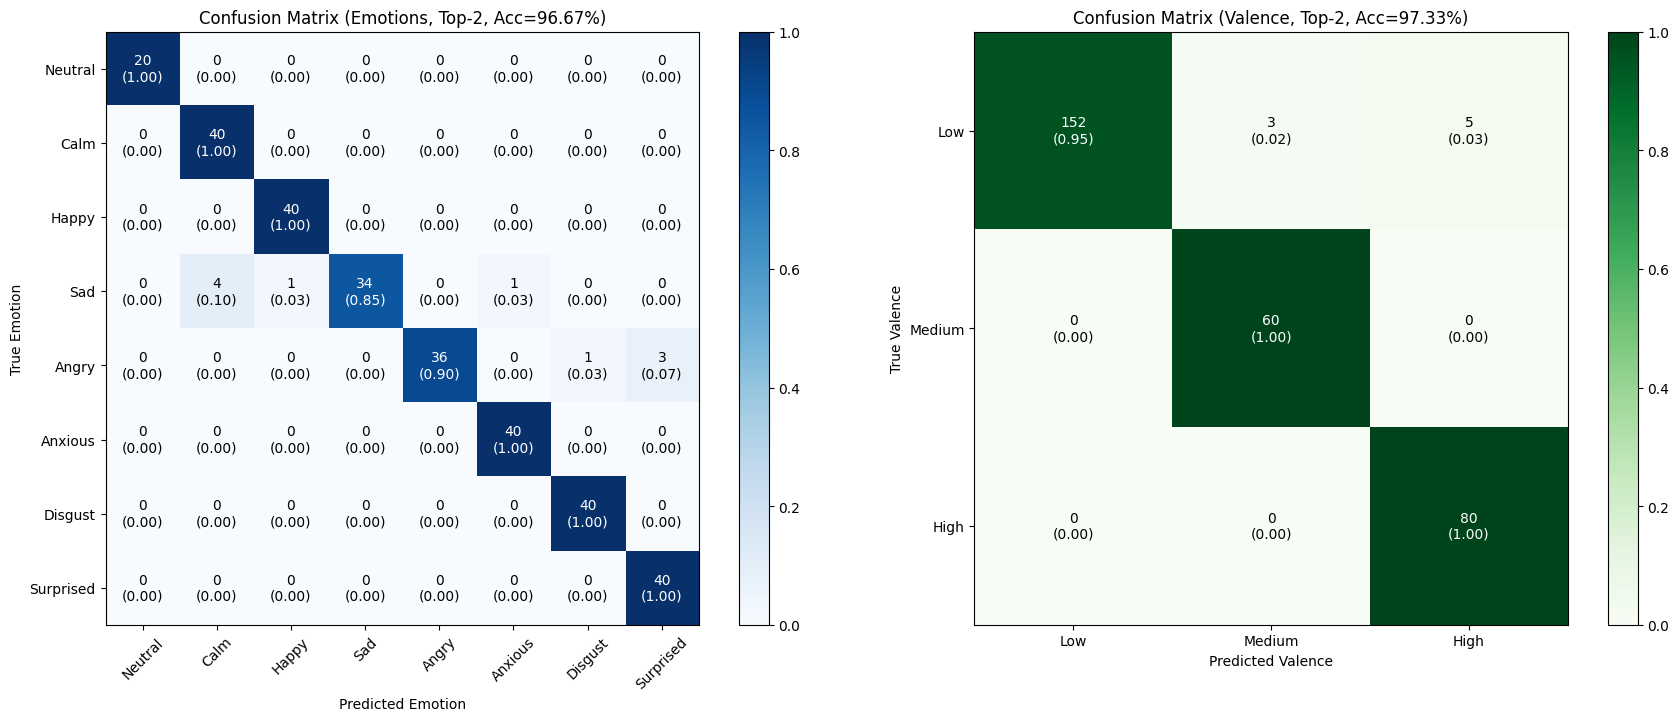


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       1.00      1.00      1.00        20
        Calm       0.91      1.00      0.95        40
       Happy       0.98      1.00      0.99        40
         Sad       1.00      0.85      0.92        40
       Angry       1.00      0.90      0.95        40
     Anxious       0.98      1.00      0.99        40
     Disgust       0.98      1.00      0.99        40
   Surprised       0.93      1.00      0.96        40

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

Emotion-Level Accuracy: 96.67%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       1.00      0.95      0.97       160
      Medium       0.95      1.00      0.98        60
        High       0.94      1.00      0.97        80

    accuracy          

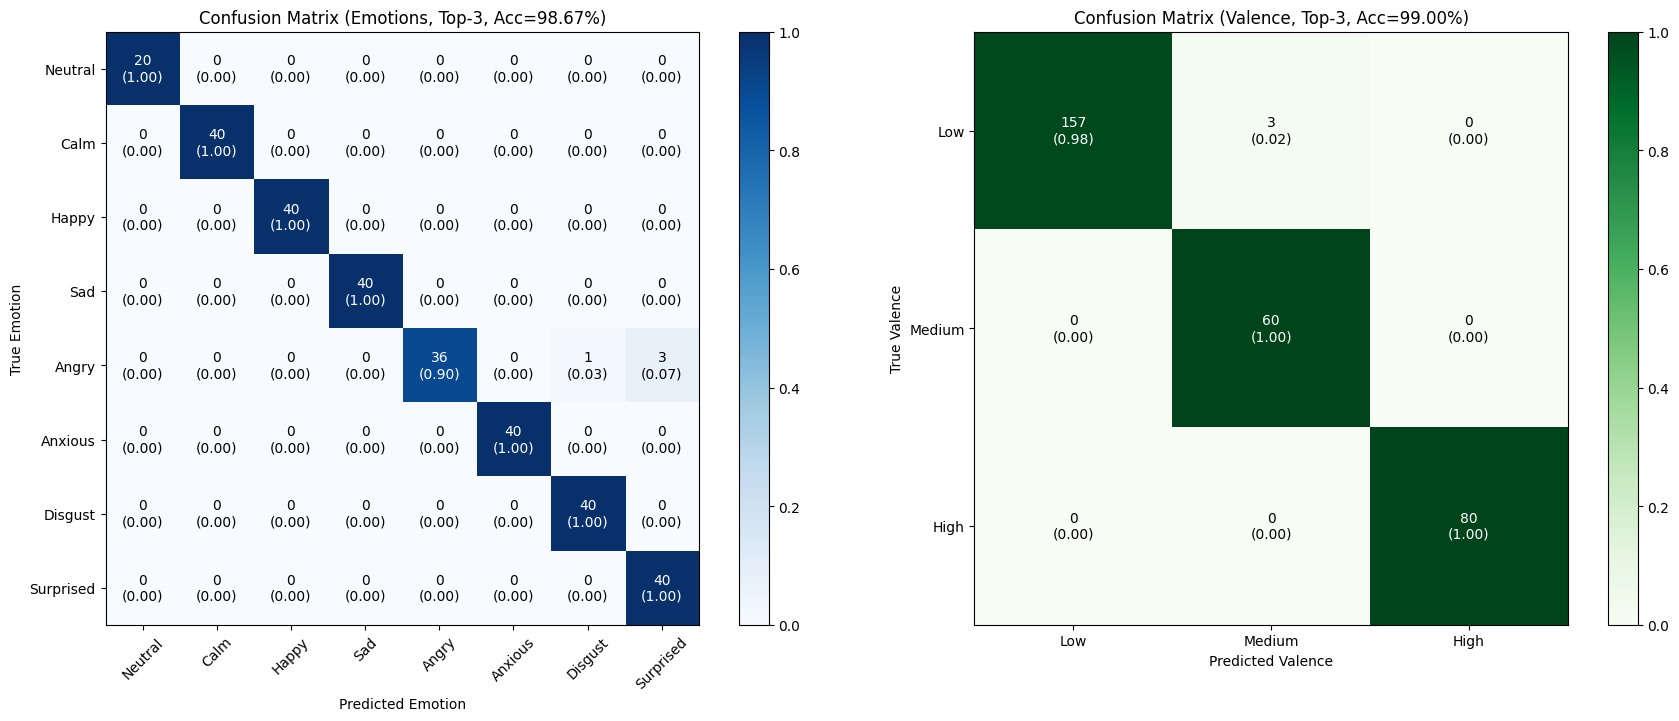


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       1.00      1.00      1.00        20
        Calm       1.00      1.00      1.00        40
       Happy       1.00      1.00      1.00        40
         Sad       1.00      1.00      1.00        40
       Angry       1.00      0.90      0.95        40
     Anxious       1.00      1.00      1.00        40
     Disgust       0.98      1.00      0.99        40
   Surprised       0.93      1.00      0.96        40

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

Emotion-Level Accuracy: 98.67%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       1.00      0.98      0.99       160
      Medium       0.95      1.00      0.98        60
        High       1.00      1.00      1.00        80

    accuracy          

In [22]:
# here normalized accuracy score is printed
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=1)
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=2)
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=3)

In [23]:
# evaluate the best model on train data
preds, targets = evaluate(model, train_loader)

# Classification accuracy ( Remember these are not normalized accuracy score)
knn_classification_accuracy(preds, targets,k=1)
knn_classification_accuracy(preds, targets,k=2)
knn_classification_accuracy(preds, targets,k=3)

MSE: 0.0039
R²: 0.9296
Euclidean Distance: 0.0525
1-NN Classification Accuracy (VAD → emotion): 0.9202
2-NN Classification Accuracy (VAD → emotion): 0.9588
3-NN Classification Accuracy (VAD → emotion): 0.9754


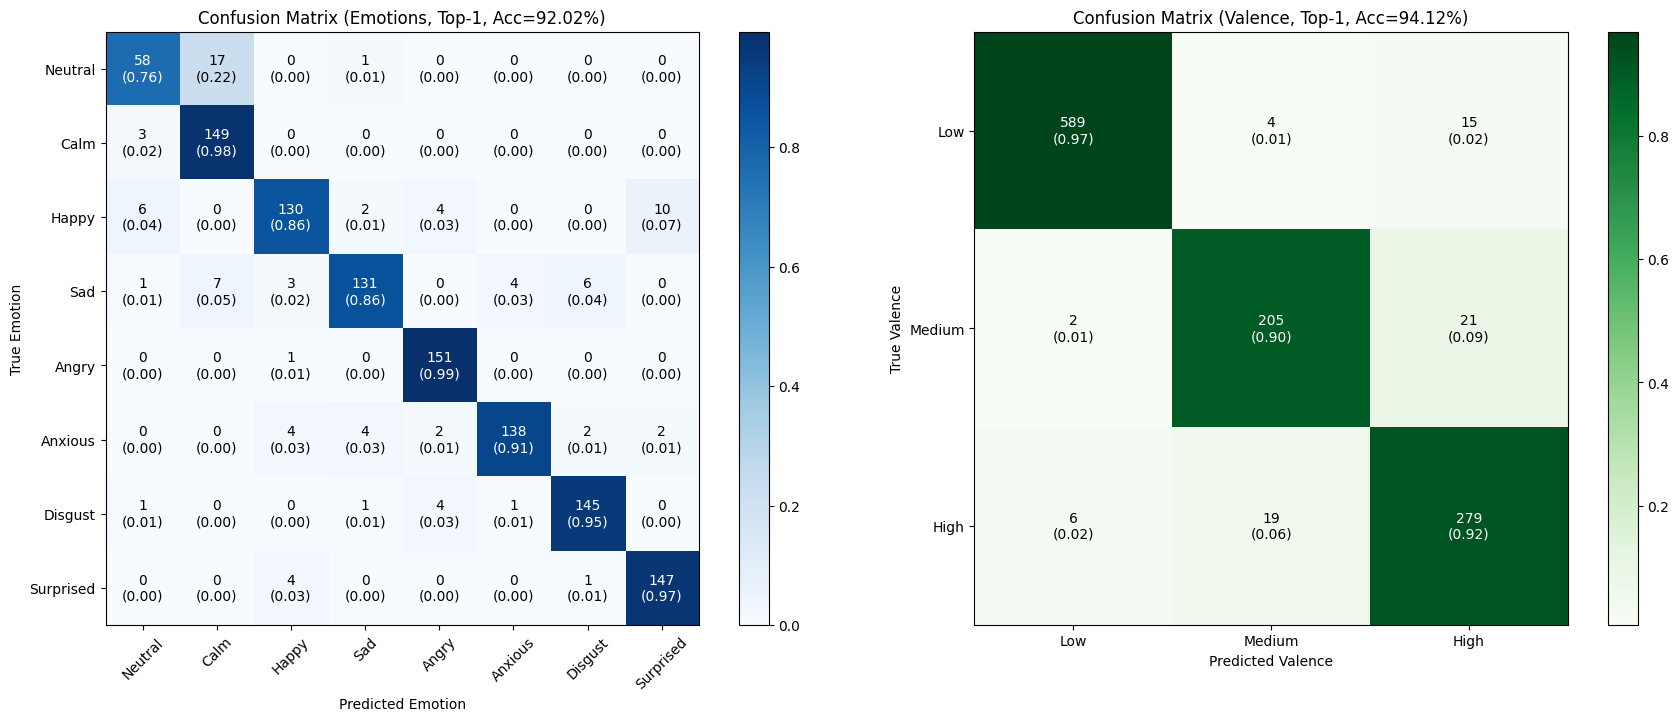


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       0.84      0.76      0.80        76
        Calm       0.86      0.98      0.92       152
       Happy       0.92      0.86      0.88       152
         Sad       0.94      0.86      0.90       152
       Angry       0.94      0.99      0.96       152
     Anxious       0.97      0.91      0.94       152
     Disgust       0.94      0.95      0.95       152
   Surprised       0.92      0.97      0.95       152

    accuracy                           0.92      1140
   macro avg       0.92      0.91      0.91      1140
weighted avg       0.92      0.92      0.92      1140

Emotion-Level Accuracy: 92.02%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       0.99      0.97      0.98       608
      Medium       0.90      0.90      0.90       228
        High       0.89      0.92      0.90       304

    accuracy          

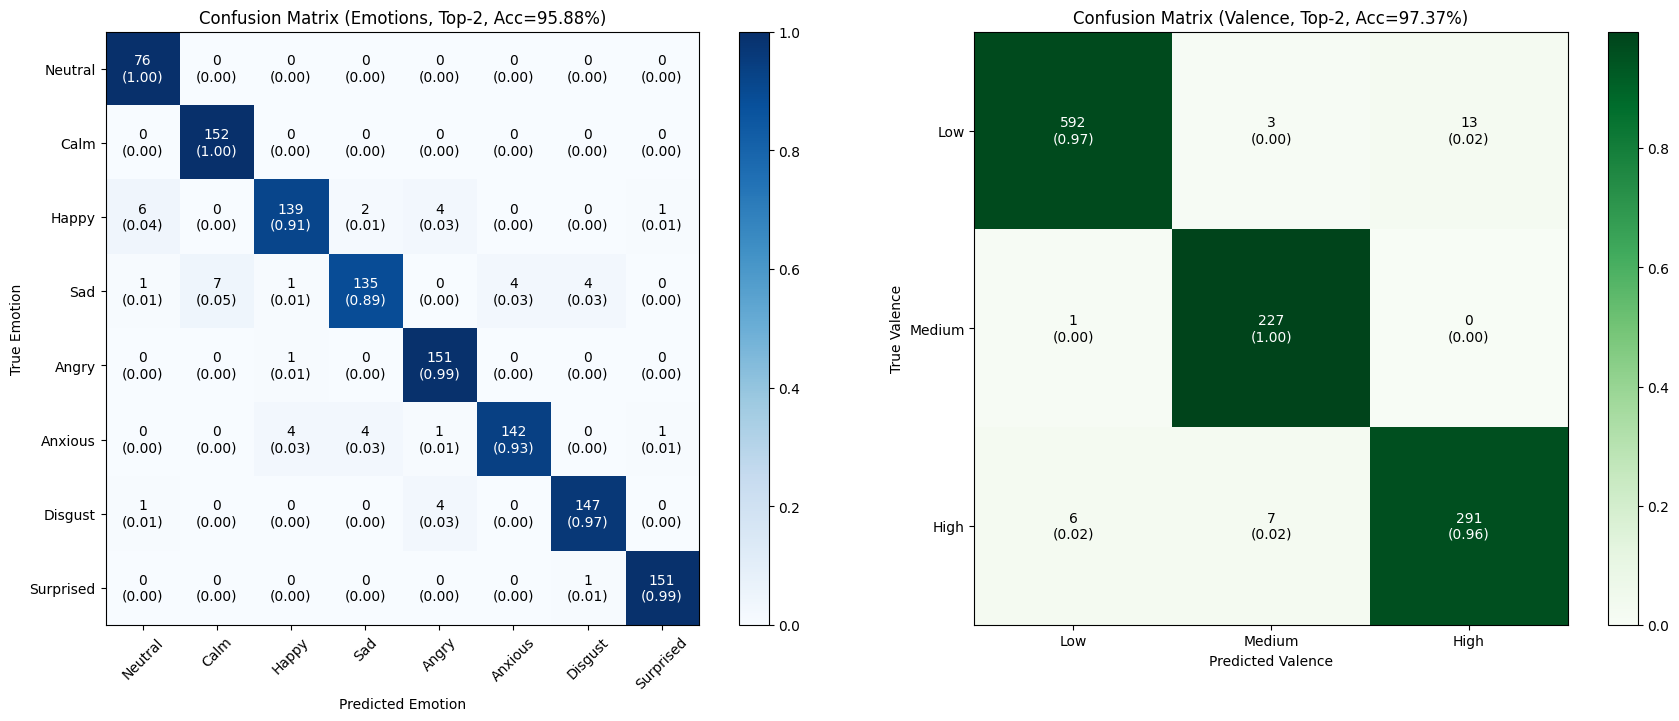


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       0.90      1.00      0.95        76
        Calm       0.96      1.00      0.98       152
       Happy       0.96      0.91      0.94       152
         Sad       0.96      0.89      0.92       152
       Angry       0.94      0.99      0.97       152
     Anxious       0.97      0.93      0.95       152
     Disgust       0.97      0.97      0.97       152
   Surprised       0.99      0.99      0.99       152

    accuracy                           0.96      1140
   macro avg       0.96      0.96      0.96      1140
weighted avg       0.96      0.96      0.96      1140

Emotion-Level Accuracy: 95.88%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       0.99      0.97      0.98       608
      Medium       0.96      1.00      0.98       228
        High       0.96      0.96      0.96       304

    accuracy          

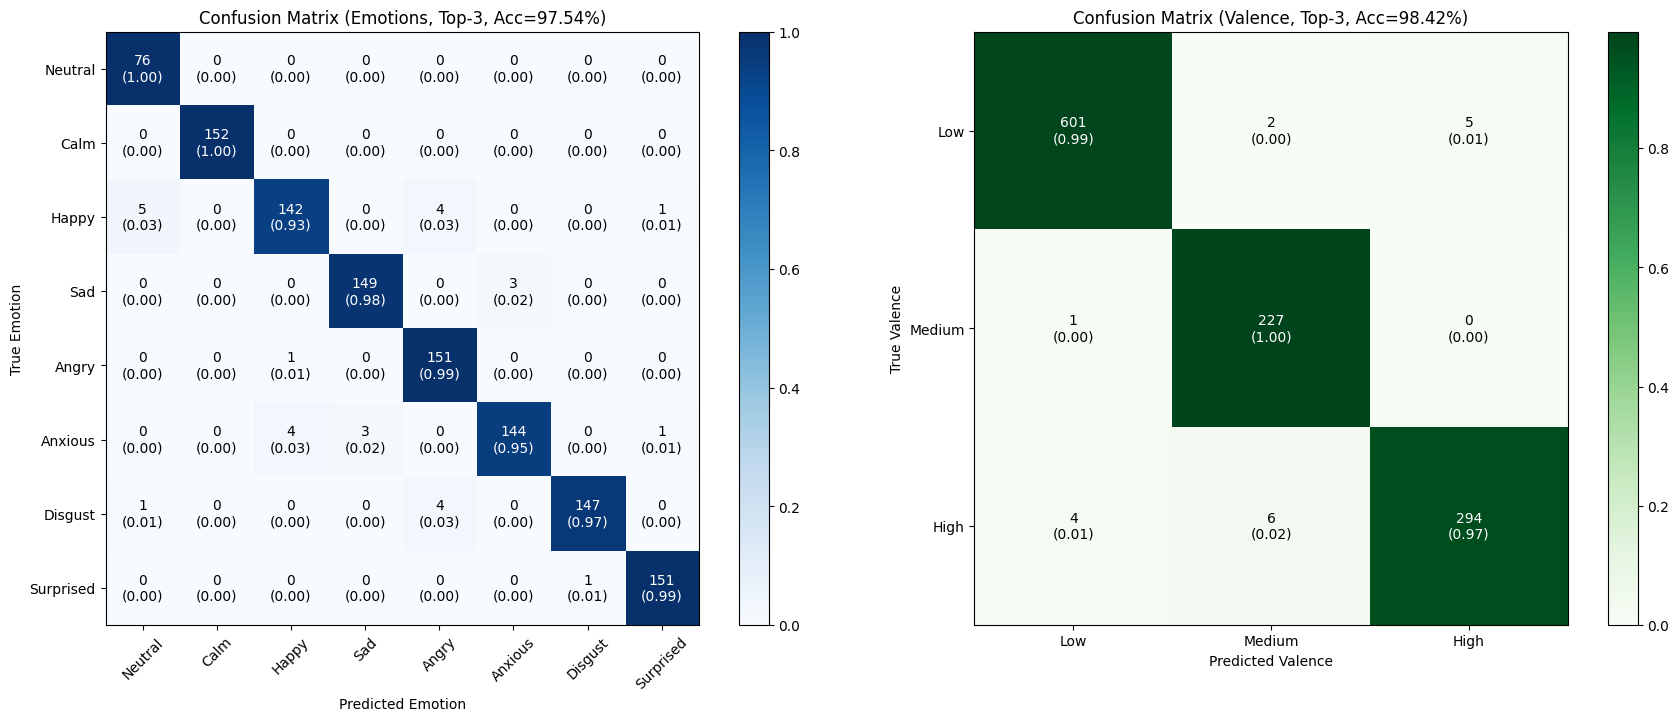


--- Emotion Classification Report ---
              precision    recall  f1-score   support

     Neutral       0.93      1.00      0.96        76
        Calm       1.00      1.00      1.00       152
       Happy       0.97      0.93      0.95       152
         Sad       0.98      0.98      0.98       152
       Angry       0.95      0.99      0.97       152
     Anxious       0.98      0.95      0.96       152
     Disgust       0.99      0.97      0.98       152
   Surprised       0.99      0.99      0.99       152

    accuracy                           0.98      1140
   macro avg       0.97      0.98      0.97      1140
weighted avg       0.98      0.98      0.98      1140

Emotion-Level Accuracy: 97.54%

--- Valence Classification Report ---
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99       608
      Medium       0.97      1.00      0.98       228
        High       0.98      0.97      0.98       304

    accuracy          

In [24]:
# here normalized accuracy score is printed
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=1)
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=2)
plot_confusion_matrix_from_vad(preds, targets, emotion_to_vad_map, emotion_valence_map, k=3)